# Calories Burnt Prediction - Exploratory Data Analysis

This notebook explores the Calories Burnt dataset.

The production preprocessing, feature engineering,
training, evaluation, and prediction pipelines are
implemented inside the `src/` package.

In [4]:
import sys
from pathlib import Path

# Go from notebooks/ -> project root
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data

In [9]:
df = load_data()
df.head()

2026-07-14 01:48:58,672 | INFO | src.utils.logger | Loading complete dataset...
2026-07-14 01:48:58,686 | INFO | src.utils.logger | Loading calories dataset...
2026-07-14 01:48:58,944 | INFO | src.utils.logger | Calories dataset loaded successfully.
2026-07-14 01:48:58,946 | INFO | src.utils.logger | Loading exercise dataset...
2026-07-14 01:48:58,998 | INFO | src.utils.logger | Exercise dataset loaded successfully.
2026-07-14 01:48:59,030 | INFO | src.utils.logger | Dataset successfully created with shape (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [10]:
df.shape

(15000, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [13]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [14]:
df.sample(5)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
10377,18414392,male,31,188.0,89.0,7.0,90.0,39.1,27.0
4368,12223324,female,69,175.0,68.0,15.0,98.0,40.0,88.0
6678,19861664,female,23,149.0,47.0,28.0,114.0,40.8,198.0
6624,15949814,female,58,162.0,60.0,21.0,106.0,40.8,140.0
2971,17532051,female,31,158.0,64.0,24.0,94.0,40.4,116.0


In [16]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

<Axes: >

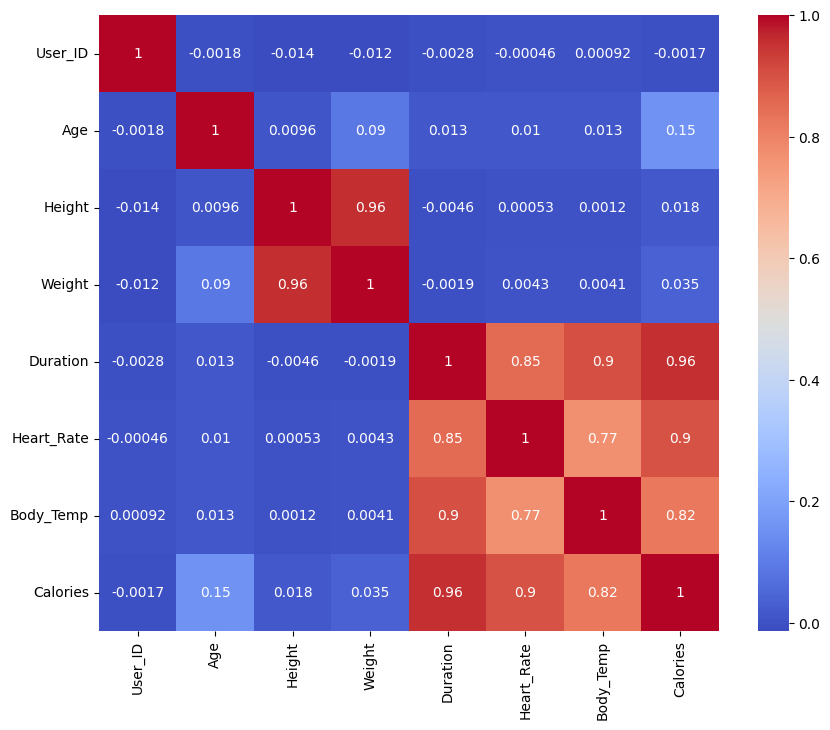

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='Age', ylabel='Count'>

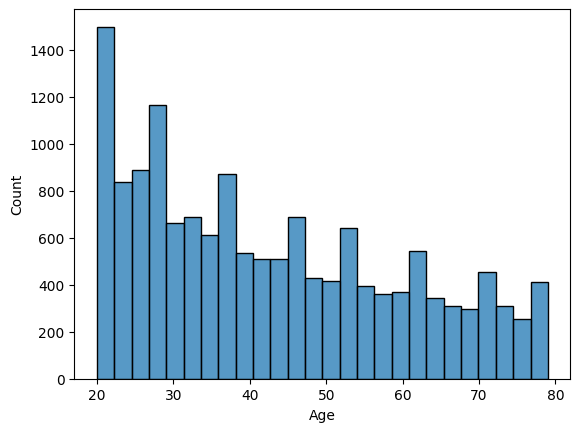

In [19]:
sns.histplot(df["Age"])

<Axes: xlabel='Weight', ylabel='Count'>

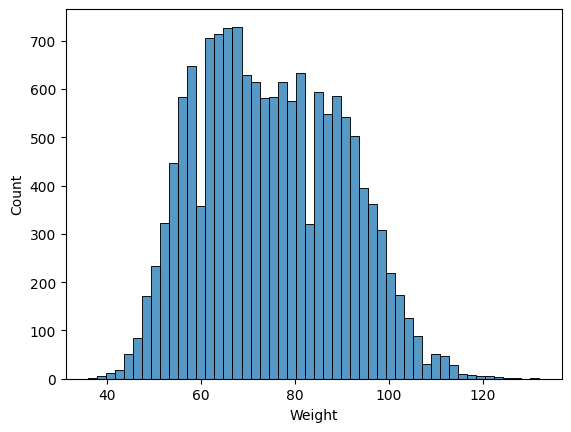

In [20]:
sns.histplot(df["Weight"])

<Axes: xlabel='Duration', ylabel='Count'>

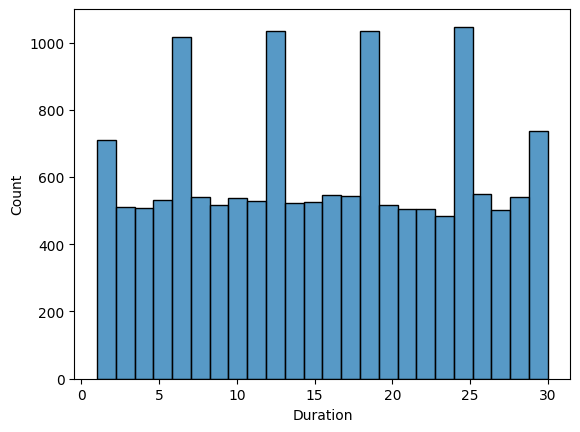

In [21]:
sns.histplot(df["Duration"])

<Axes: xlabel='Duration', ylabel='Calories'>

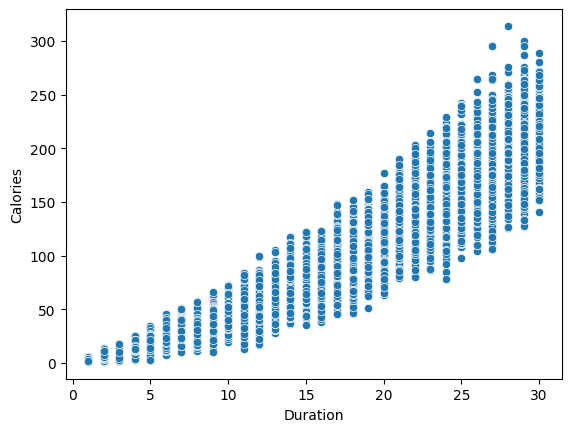

In [22]:
sns.scatterplot(
    data=df,
    x="Duration",
    y="Calories"
)

<Axes: xlabel='Heart_Rate', ylabel='Calories'>

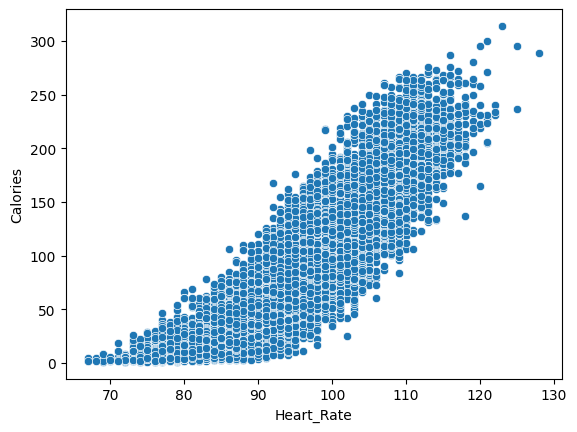

In [23]:
sns.scatterplot(
    data=df,
    x="Heart_Rate",
    y="Calories"
)

<Axes: xlabel='Gender', ylabel='Calories'>

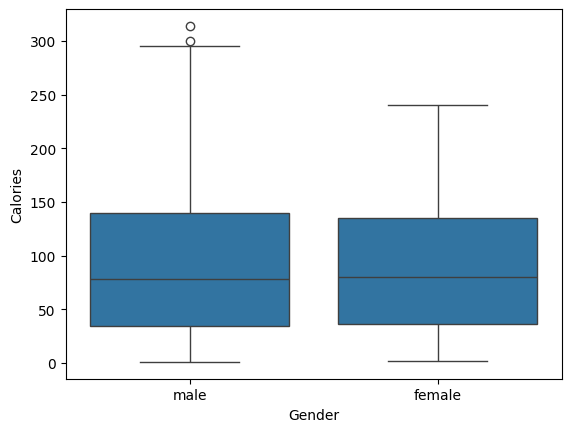

In [24]:
sns.boxplot(
    data=df,
    x="Gender",
    y="Calories"
)

## Key Findings

- Dataset contains 15,000 observations.
- No missing values.
- No duplicate rows.
- Calories strongly correlate with Duration.
- Heart Rate is highly correlated with Calories.
- Body Temperature has moderate correlation.
- Gender shows a small difference in calorie expenditure.